<a href="https://colab.research.google.com/github/christinakoump/Parkinson-s-disease-severity-assessment-on-the-UPDRS-by-analyzing-the-speech-signal/blob/main/PD's%20severity%20assessment%20by%20analyzing%20the%20speech%20signal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print(torch.cuda.is_available())
!nvidia-smi


### Explore the Dataset Directory Structure

This cell scans the entire PC-GITA dataset directory recursively to inspect its organization. For each folder, it identifies the immediate subdirectories and counts the number of `.wav` audio files stored directly within it. The resulting summary provides a concise overview of the dataset hierarchy, helping verify that the files are organized as expected before proceeding with data loading and preprocessing.

In [ ]:
import os
from collections import defaultdict
root_path = "/media/blue/ckoumpo/pcgita/PC-GITA_per_task_44100Hz/"

folder_structure = defaultdict(dict)
####it was list

for dirpath, dirnames, filenames in os.walk(root_path):
    rel_path = os.path.relpath(dirpath, root_path)

    if rel_path == ".":
        continue

    subfolders = [name for name in os.listdir(dirpath) if os.path.isdir(os.path.join(dirpath, name))]
    wav_count = sum(1 for f in filenames if f.lower().endswith('.wav'))

    folder_structure[rel_path] = {
        "Subfolders": subfolders,
        "WAV files": wav_count
    }

for path, info in folder_structure.items():
    print(f" {path}")
    if info["Subfolders"]:
        print(f"   ├─ Subfolders: {', '.join(info['Subfolders'])}")
    if info["WAV files"] > 0:
        print(f"   └─ WAV files: {info['WAV files']}")


### Create an Index of All Audio Recordings

This cell traverses the entire PC-GITA dataset and creates a structured index of every `.wav` recording. For each audio file, it extracts the recording task, speaker identifier, relative and absolute file paths, and assigns a class label based on the folder hierarchy (Parkinson's disease, healthy control, or unknown). The collected metadata are stored in a Pandas DataFrame and exported as a CSV file, providing a centralized index that simplifies data loading, filtering, and subsequent analysis.

In [ ]:
import os
import pandas as pd

root_path = "/media/blue/ckoumpo/pcgita/PC-GITA_per_task_44100Hz/"
save_csv = "/media/blue/ckoumpo/pcgita/PCGITA_RESULTS/pcgita_file_index.csv"

folder_records = []

for dirpath, _, filenames in os.walk(root_path):
    for fname in filenames:
        if not fname.lower().endswith(".wav"):
            continue

        full_path = os.path.join(dirpath, fname)
        relative_path = os.path.relpath(full_path, root_path)
        parts = relative_path.split(os.sep)

        task = parts[0]
        speaker_id = fname.split("_")[0]

        path_lower = [p.lower() for p in parts]
        if any(x in p for p in path_lower for x in ["patologica", "parkinson", "pd"]):
            label = "PD"
        elif any(x in p for p in path_lower for x in ["control", "hc", "normal"]):
            label = "HC"
        else:
            label = "Unknown"

        folder_records.append({
            "Task": task,
            "Label": label,
            "Speaker_ID": speaker_id,
            "Relative Path": relative_path,
            "Full Path": full_path,
        })

df = pd.DataFrame(folder_records)
os.makedirs(os.path.dirname(save_csv), exist_ok=True)
df.to_csv(save_csv, index=False)

print(f"Indexed WAV files: {len(df)}")
df.head()


In [ ]:
num_pd_speakers = df[df["Label"] == "PD"]["Speaker_ID"].nunique()
print("Number of PD speakers:", num_pd_speakers)
num_hc_speakers = df[df["Label"] == "HC"]["Speaker_ID"].nunique()
print("Number of HC speakers:", num_hc_speakers)


### Merge File Index with Clinical Metadata

This cell loads the clinical metadata provided with the PC-GITA dataset and standardizes the column names for consistency. It then merges the metadata with the previously created audio file index using the speaker identifier as the matching key. After the merge, recordings from PD and HC are retained, while entries with missing speaker information or incomplete clinical measurements are removed. The resulting cleaned metadata table, containing both file information and participant clinical characteristics, is saved as a CSV file for use in subsequent analyses.

In [ ]:
import pandas as pd
import openpyxl

xlsx_path = "/media/blue/ckoumpo/pcgita/PC-GITA_per_task_44100Hz/Copia de PCGITA_metadata.xlsx"
file_index_path = "/media/blue/ckoumpo/pcgita/PCGITA_RESULTS/pcgita_file_index.csv"
output_csv = "/media/blue/ckoumpo/pcgita/PCGITA_RESULTS/pcgita_metadata_cleaned.csv"

df_meta = pd.read_excel(xlsx_path)
df_meta.columns = df_meta.columns.str.strip().str.title()

df_meta = df_meta.rename(columns={
    "Recoding Original Name": "Speaker_ID",
    "Updrs": "UPDRS_total",
    "H/Y": "Hoehn_Yahr",
    "Sex": "Gender",
    "Age": "Age",
    "Time After Diagnosis": "After_Diagnosis"
})

df_index = pd.read_csv(file_index_path)

df_meta["Speaker_ID"] = df_meta["Speaker_ID"].astype(str).str.strip()
df_index["Speaker_ID"] = df_index["Speaker_ID"].astype(str).str.strip()

df_merged = pd.merge(df_index, df_meta, on="Speaker_ID", how="left")

df_merged = df_merged[df_merged["Label"].isin(["PD", "HC"])]
df_merged = df_merged[df_merged["Speaker_ID"].notna()]
df_merged = df_merged[df_merged["UPDRS_total"].notna()]

df_cleaned = df_merged.dropna(subset=["Age", "Gender", "Hoehn_Yahr", "After_Diagnosis"])

df_cleaned.to_csv(output_csv, index=False)
df_cleaned.head()


### Dataset Statistics Overview

This cell computes basic statistics from the cleaned dataset to validate class distribution and data integrity. It calculates the number of unique speakers for each class (PD and HC), ensuring speaker-level balance can be assessed. It also counts the total number of `.wav` files included in the final metadata table and summarizes the overall label distribution. These checks help confirm that the dataset is properly filtered and suitable for downstream machine learning or statistical analysis. -- 50 PD speakers and their recordings are 1099

In [ ]:
# Count unique PD speakers
num_pd_speakers = df_cleaned[df_cleaned["Label"] == "PD"]["Speaker_ID"].nunique()
print("Number of PD speakers:", num_pd_speakers)

# Count unique HC speakers
num_hc_speakers = df_cleaned[df_cleaned["Label"] == "HC"]["Speaker_ID"].nunique()
print("Number of HC speakers:", num_hc_speakers)
#######
# Count number of .wav files in df_cleaned
num_wav_files = df_cleaned["Full Path"].str.lower().str.endswith(".wav").sum()
print("Number of .wav files in metadata:", num_wav_files)
###
df_cleaned["Label"].value_counts()


In [ ]:
import pandas as pd

df = pd.read_csv("/media/blue/ckoumpo/pcgita/PCGITA_RESULTS/pcgita_metadata_cleaned.csv")

print("UPDRS mean:", df["UPDRS_total"].mean())
print("UPDRS std :", df["UPDRS_total"].std())
print("UPDRS min :", df["UPDRS_total"].min())
print("UPDRS max :", df["UPDRS_total"].max())


### Load Pretrained WavLM Model for Speech Embeddings

This cell initializes a pretrained **WavLM-Base** model to convert raw speech waveforms into fixed-dimensional acoustic embeddings. It sets up the computation device (GPU if available) and loads both the feature extractor and the neural network model from Hugging Face.

The feature extractor normalizes raw audio into the expected input format, while the WavLM model produces contextual speech representations from the waveform. Audio is resampled to 16 kHz, converted to mono, and truncated to a maximum duration of 10 seconds for memory efficiency. The final embedding is obtained by averaging the last hidden layer representations, producing a compact 768-dimensional vector per audio file, suitable for downstream machine learning tasks such as classification or statistical analysis.

In [ ]:
#convert raw speech waveforms to fixed-dimensional acoustic embeddings
import torch
import torchaudio
import numpy as np
from transformers import WavLMModel, Wav2Vec2FeatureExtractor

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

#Wav2Vec2FeatureExtractor is initialized using pretrained parameters from WavLM-Base
#feature_extractor: raw waveform → standardized float tensor → WavLM input space
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    "microsoft/wavlm-base",
    return_attention_mask=True
)
model = WavLMModel.from_pretrained("microsoft/wavlm-base").to(device)
model.eval()

torch.backends.cudnn.benchmark = True

TARGET_SR = 16000
MAX_SEC = 10  # max 10 seconds per clip for memory efficiency

def load_wav(path):
    wav, sr = torchaudio.load(path)
    wav = wav.mean(dim=0)  # mono
    if sr != TARGET_SR:
        wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
    max_samples = TARGET_SR * MAX_SEC
    if wav.size(0) > max_samples:
        wav = wav[:max_samples]  # trim long audio
    return wav

def extract_embedding(path):
    wav = load_wav(path)

    inputs = feature_extractor(
        wav,
        sampling_rate=TARGET_SR,
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        outputs = model(inputs.input_values.to(device))

    emb = outputs.last_hidden_state.mean(dim=1).squeeze(0) #embeddings from last layer
    #768 is the hidden size of the WavLM-Base model
    return emb.cpu().numpy()



### Contrastive Learning Pipeline for Speaker-Aware Speech Embeddings

This cell defines a full contrastive learning setup to fine-tune the pretrained WavLM model using speaker-based relationships in the PC-GITA dataset.

A custom dataset generates triplets of audio samples: an anchor utterance, a positive sample from the same speaker, and a negative sample from a different speaker. This structure encourages the model to learn speaker-discriminative representations.

A custom `collate_fn` groups waveform triplets into batches, and a `DataLoader` is configured for efficient streaming with small batch size to reduce memory usage.

The training objective is a contrastive loss function based on cosine similarity, where embeddings from the same speaker are pulled closer together while embeddings from different speakers are pushed apart using a temperature-scaled softmax formulation.

During training, raw waveforms are converted into model inputs using the WavLM feature extractor, passed through the model to obtain embeddings, and optimized using AdamW with mixed-precision (AMP) for efficiency. GPU memory is actively managed after each iteration to prevent overflow.

The model is trained for multiple epochs, and the average contrastive loss per epoch is reported to monitor convergence.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import torch
import torchaudio

# -------------------------------
# 2- Dataset
# -------------------------------
class ContrastiveDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.groups = df.groupby("Speaker_ID")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pos = self.groups.get_group(row["Speaker_ID"]).sample(1).iloc[0]
        neg = self.df[self.df["Speaker_ID"] != row["Speaker_ID"]].sample(1).iloc[0]
        return load_wav(row["Full Path"]), load_wav(pos["Full Path"]), load_wav(neg["Full Path"])


# -------------------------------
# 3- Collate function, Converts a list of triplets into three separate lists of anchor, positive, negative waveforms
# -------------------------------
def collate_fn(batch):
    a, p, n = zip(*batch)
    return list(a), list(p), list(n)


# -------------------------------
# 4- DataLoader
# -------------------------------
loader = DataLoader(
    ContrastiveDataset(df),
    batch_size=1,   # memory-friendly
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn
)


# -------------------------------
# 5- Optimizer + AMP scaler
# -------------------------------
optimizer = AdamW(model.parameters(), lr=1e-5)
scaler = torch.amp.GradScaler(device="cuda")  # for mixed precision


# -------------------------------
# 6- Contrastive loss helper
# -------------------------------
import torch.nn.functional as F

def contrastive_loss(z1, z2, z3, temperature=0.1):
    z1 = F.normalize(z1, dim=-1) #this transforms embeddings into unit vectors
    z2 = F.normalize(z2, dim=-1)
    z3 = F.normalize(z3, dim=-1)
    pos_sim = torch.exp(torch.sum(z1 * z2, dim=-1) / temperature) #Dot product becomes cosine similarity, sim/t
    neg_sim = torch.exp(torch.sum(z1 * z3, dim=-1) / temperature)
    return -torch.log(pos_sim / (pos_sim + neg_sim)).mean()


# -------------------------------
# 7- Training loop
# -------------------------------
model.train()
for epoch in range(6):
    total_loss = 0
    for step, (a, p, n) in enumerate(loader):

        # convert to numpy arrays before feature extractor
        a_inputs = feature_extractor([x.numpy() for x in a],
                                     sampling_rate=TARGET_SR,
                                     return_tensors="pt",
                                     padding=True).input_values.to(device)
        p_inputs = feature_extractor([x.numpy() for x in p],
                                     sampling_rate=TARGET_SR,
                                     return_tensors="pt",
                                     padding=True).input_values.to(device)
        n_inputs = feature_extractor([x.numpy() for x in n],
                                     sampling_rate=TARGET_SR,
                                     return_tensors="pt",
                                     padding=True).input_values.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda"):
            za = model(a_inputs).last_hidden_state.mean(dim=1)
            zp = model(p_inputs).last_hidden_state.mean(dim=1)
            zn = model(n_inputs).last_hidden_state.mean(dim=1)
            loss = contrastive_loss(za, zp, zn) #here is called the contrastive loss

        scaler.scale(loss).backward() ## compute gradients
        scaler.step(optimizer) ## update model weights using gradients
        scaler.update()

        total_loss += loss.item()

        # -------------------------------
        # free GPU memory

        del a_inputs, p_inputs, n_inputs, za, zp, zn
        del a, p, n
        torch.cuda.empty_cache()
        import gc
        gc.collect()

    print(f"Epoch {epoch+1} | Loss: {total_loss / len(loader):.4f}")

model.eval()


In [ ]:
import matplotlib.pyplot as plt

epoch_losses = [0.5624, 0.3819, 0.2331, 0.1914, 0.1889, 0.1214]
epochs = range(1, len(epoch_losses) + 1)

plt.plot(epochs, epoch_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)

plt.gca().set_facecolor("white")
plt.show()


### Freeze Model Parameters

This cell disables gradient updates for all parameters in the WavLM model. By setting `requires_grad = False`, the pretrained weights are frozen, meaning they will not be updated during training. This is typically done when using the model as a fixed feature extractor to reduce computational cost and prevent overfitting, especially when training with limited data.

In [ ]:
for p in model.parameters():
    p.requires_grad = False #parameters freeze


### Generate Embeddings and Aggregate to Speaker Level

This cell computes speech embeddings for each audio file using the pretrained WavLM-based `extract_embedding` function and assigns diagnostic labels based on filename patterns.

After extracting per-utterance embeddings, the data is aggregated at the speaker level by averaging all embeddings belonging to the same speaker. This produces a single fixed-dimensional representation per speaker, along with averaged clinical scores (UPDRS) and a representative diagnostic label.

The final outputs are:

- `X`: speaker-level embedding matrix (input features)
- `y`: corresponding UPDRS scores (regression target)
- `labels`: speaker-level diagnostic classes (PD / HC)

This structure enables downstream modeling at the speaker level rather than the utterance level, improving robustness and reducing redundancy.

In [ ]:
df["Embedding"] = df["Full Path"].apply(extract_embedding)

def infer_label(path):
    p = path.lower()
    if any(x in p for x in ["patologica", "parkinson", "pd"]):
        return "PD"
    elif any(x in p for x in ["control", "hc", "normal"]):
        return "HC"
    else:
        return "Unknown"

df["Label"] = df["Full Path"].apply(infer_label)

speaker_df = (
    df.groupby("Speaker_ID")
      .agg({
          "Embedding": lambda x: np.mean(np.stack(x), axis=0),
          "UPDRS_total": "mean",
          "Label": "first"   # ← THIS LINE WAS MISSING
      })
      .reset_index()
)

X = np.stack(speaker_df["Embedding"].values)
y = speaker_df["UPDRS_total"].values
labels = speaker_df["Label"].values


### Leave-One-Speaker-Out Regression for UPDRS Prediction (PD Only)

This cell evaluates how well speaker-level embeddings predict disease severity (UPDRS total score) for Parkinson’s disease speakers only.

The dataset is filtered to include only PD speakers, and a Leave-One-Out Cross-Validation (LOOCV) scheme is applied at the speaker level. For each iteration, one speaker is held out as the test case while the remaining speakers are used for training.

Before training, the UPDRS target values are standardized using z-score normalization to improve regression stability. A Ridge regression model is then trained on the training embeddings and used to predict the held-out speaker’s severity score. Predictions are converted back to the original scale for interpretability.

The final output is a DataFrame containing, for each PD speaker:

- Speaker ID  
- Ground-truth UPDRS score  
- Predicted UPDRS score  

This setup provides a strict evaluation of generalization performance under a leave-one-subject-out protocol.

In [ ]:

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error
import numpy as np

# Filter only PD speakers
mask = speaker_df["Label"] == "PD"
X = np.stack(speaker_df["Embedding"].values)[mask]
y = speaker_df["UPDRS_total"].values[mask]
speaker_ids = speaker_df["Speaker_ID"].values[mask]

loo = LeaveOneOut()

pred_list = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Standardize labels for regression - z normalization
    scaler = StandardScaler()
    y_train_z = scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_test_z = scaler.transform(y_test.reshape(-1, 1)).ravel()

    # Train Ridge regression
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train_z)

    # Predict and convert back to raw UPDRS units
    y_pred_z = model.predict(X_test)
    y_pred_raw = scaler.inverse_transform(y_pred_z.reshape(-1, 1)).ravel()[0]

    pred_list.append({
        "Speaker_ID": speaker_ids[test_idx[0]],
        "Ground_Truth_UPDRS": y_test[0],
        "Predicted_UPDRS": y_pred_raw
    })

# Convert to DataFrame
results_df = pd.DataFrame(pred_list)
print(results_df)


### Leave-One-Speaker-Out Evaluation (RMSE) for UPDRS Prediction

This cell evaluates regression performance for predicting UPDRS scores using speaker-level embeddings, restricted to Parkinson’s disease speakers.

A Leave-One-Out Cross-Validation (LOOCV) strategy is used, where each speaker is iteratively held out as the test sample while the model is trained on all remaining speakers. This ensures evaluation is performed at the strict speaker level, preventing data leakage.

UPDRS values are standardized using z-score normalization within each training fold to stabilize regression learning. A Ridge regression model is trained on the embeddings and evaluated on the held-out speaker. Performance is measured using Root Mean Squared Error (RMSE) in the normalized target space.

The final output reports the mean RMSE across all speakers, providing an overall estimate of prediction error and model generalization capability for severity estimation.

With the above cell:Same LOOCV training loop, Same Ridge regression
The only difference is that:
It does NOT store predictions
It directly computes error per fold

In [ ]:
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
import numpy as np

X = np.stack(speaker_df["Embedding"].values)
y = speaker_df["UPDRS_total"].values  # raw UPDRS

mask = speaker_df["Label"] == "PD"
X = X[mask]
y = y[mask]

loo = LeaveOneOut()
rmses = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    y_train_z = scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_test_z = scaler.transform(y_test.reshape(-1, 1)).ravel()

    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train_z)

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test_z, y_pred))
    rmses.append(rmse)

print("Mean RMSE:", np.mean(rmses))


### Correlation and Error Metrics for UPDRS Prediction

This cell evaluates the relationship between predicted and true UPDRS scores using standard statistical metrics.

It computes:

- **Pearson correlation (r)**: measures linear correlation between predicted and true values.
- **Spearman correlation (ρ)**: measures rank-based (monotonic) relationship, robust to non-linear effects.
- **MAE (Mean Absolute Error)**: measures average absolute deviation between predictions and ground truth.

Together, these metrics provide complementary perspectives: correlation captures agreement in trends, while MAE quantifies absolute prediction error.

In [ ]:
pearson_corr, pearson_p = pearsonr(y_true, y_pred)
spearman_corr, spearman_p = spearmanr(y_true, y_pred)

print(f"Pearson r: {pearson_corr:.3f} (p={pearson_p:.4f})")
print(f"Spearman ρ: {spearman_corr:.3f} (p={spearman_p:.4f})")
print(f"MAE: {mae:.2f}")


In [ ]:
import matplotlib.pyplot as plt

# Force white figure and axes, ignoring dark mode
plt.rcParams.update({
    'figure.facecolor': 'white',   # figure background
    'axes.facecolor': 'white',     # axes background
    'axes.edgecolor': 'black',     # axes border
    'axes.labelcolor': 'black',    # x/y label color
    'xtick.color': 'black',        # x tick color
    'ytick.color': 'black',        # y tick color
    'text.color': 'black',         # text color
})

fig, ax = plt.subplots()

ax.scatter(y_true, y_pred, color='blue')
ax.plot([min(y_true), max(y_true)],
        [min(y_true), max(y_true)],
        linestyle='--', color='red')

ax.set_xlabel("Ground Truth UPDRS")
ax.set_ylabel("Predicted UPDRS")
ax.set_title("Predicted vs True UPDRS (LOOCV)")

ax.grid(True, color='gray', linestyle='--', alpha=0.5)

plt.show()


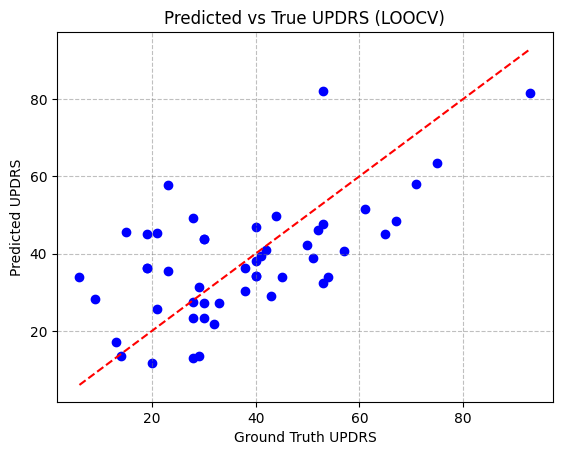